In [1]:
import keras
from sklearn.model_selection import train_test_split

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

In [3]:
model = keras.Sequential()

In [4]:
model.add(keras.layers.Input(shape=(28, 28, 1)))

In [5]:
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'))

In [6]:
model.add(keras.layers.MaxPooling2D(2))

In [7]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'))

In [8]:
model.add(keras.layers.MaxPooling2D(2))

In [9]:
model.add(keras.layers.Flatten())

In [10]:
model.add(keras.layers.Dense(100, activation='relu'))

In [11]:
model.add(keras.layers.Dropout(0.4))

In [12]:
model.add(keras.layers.Dense(10, activation='softmax'))

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

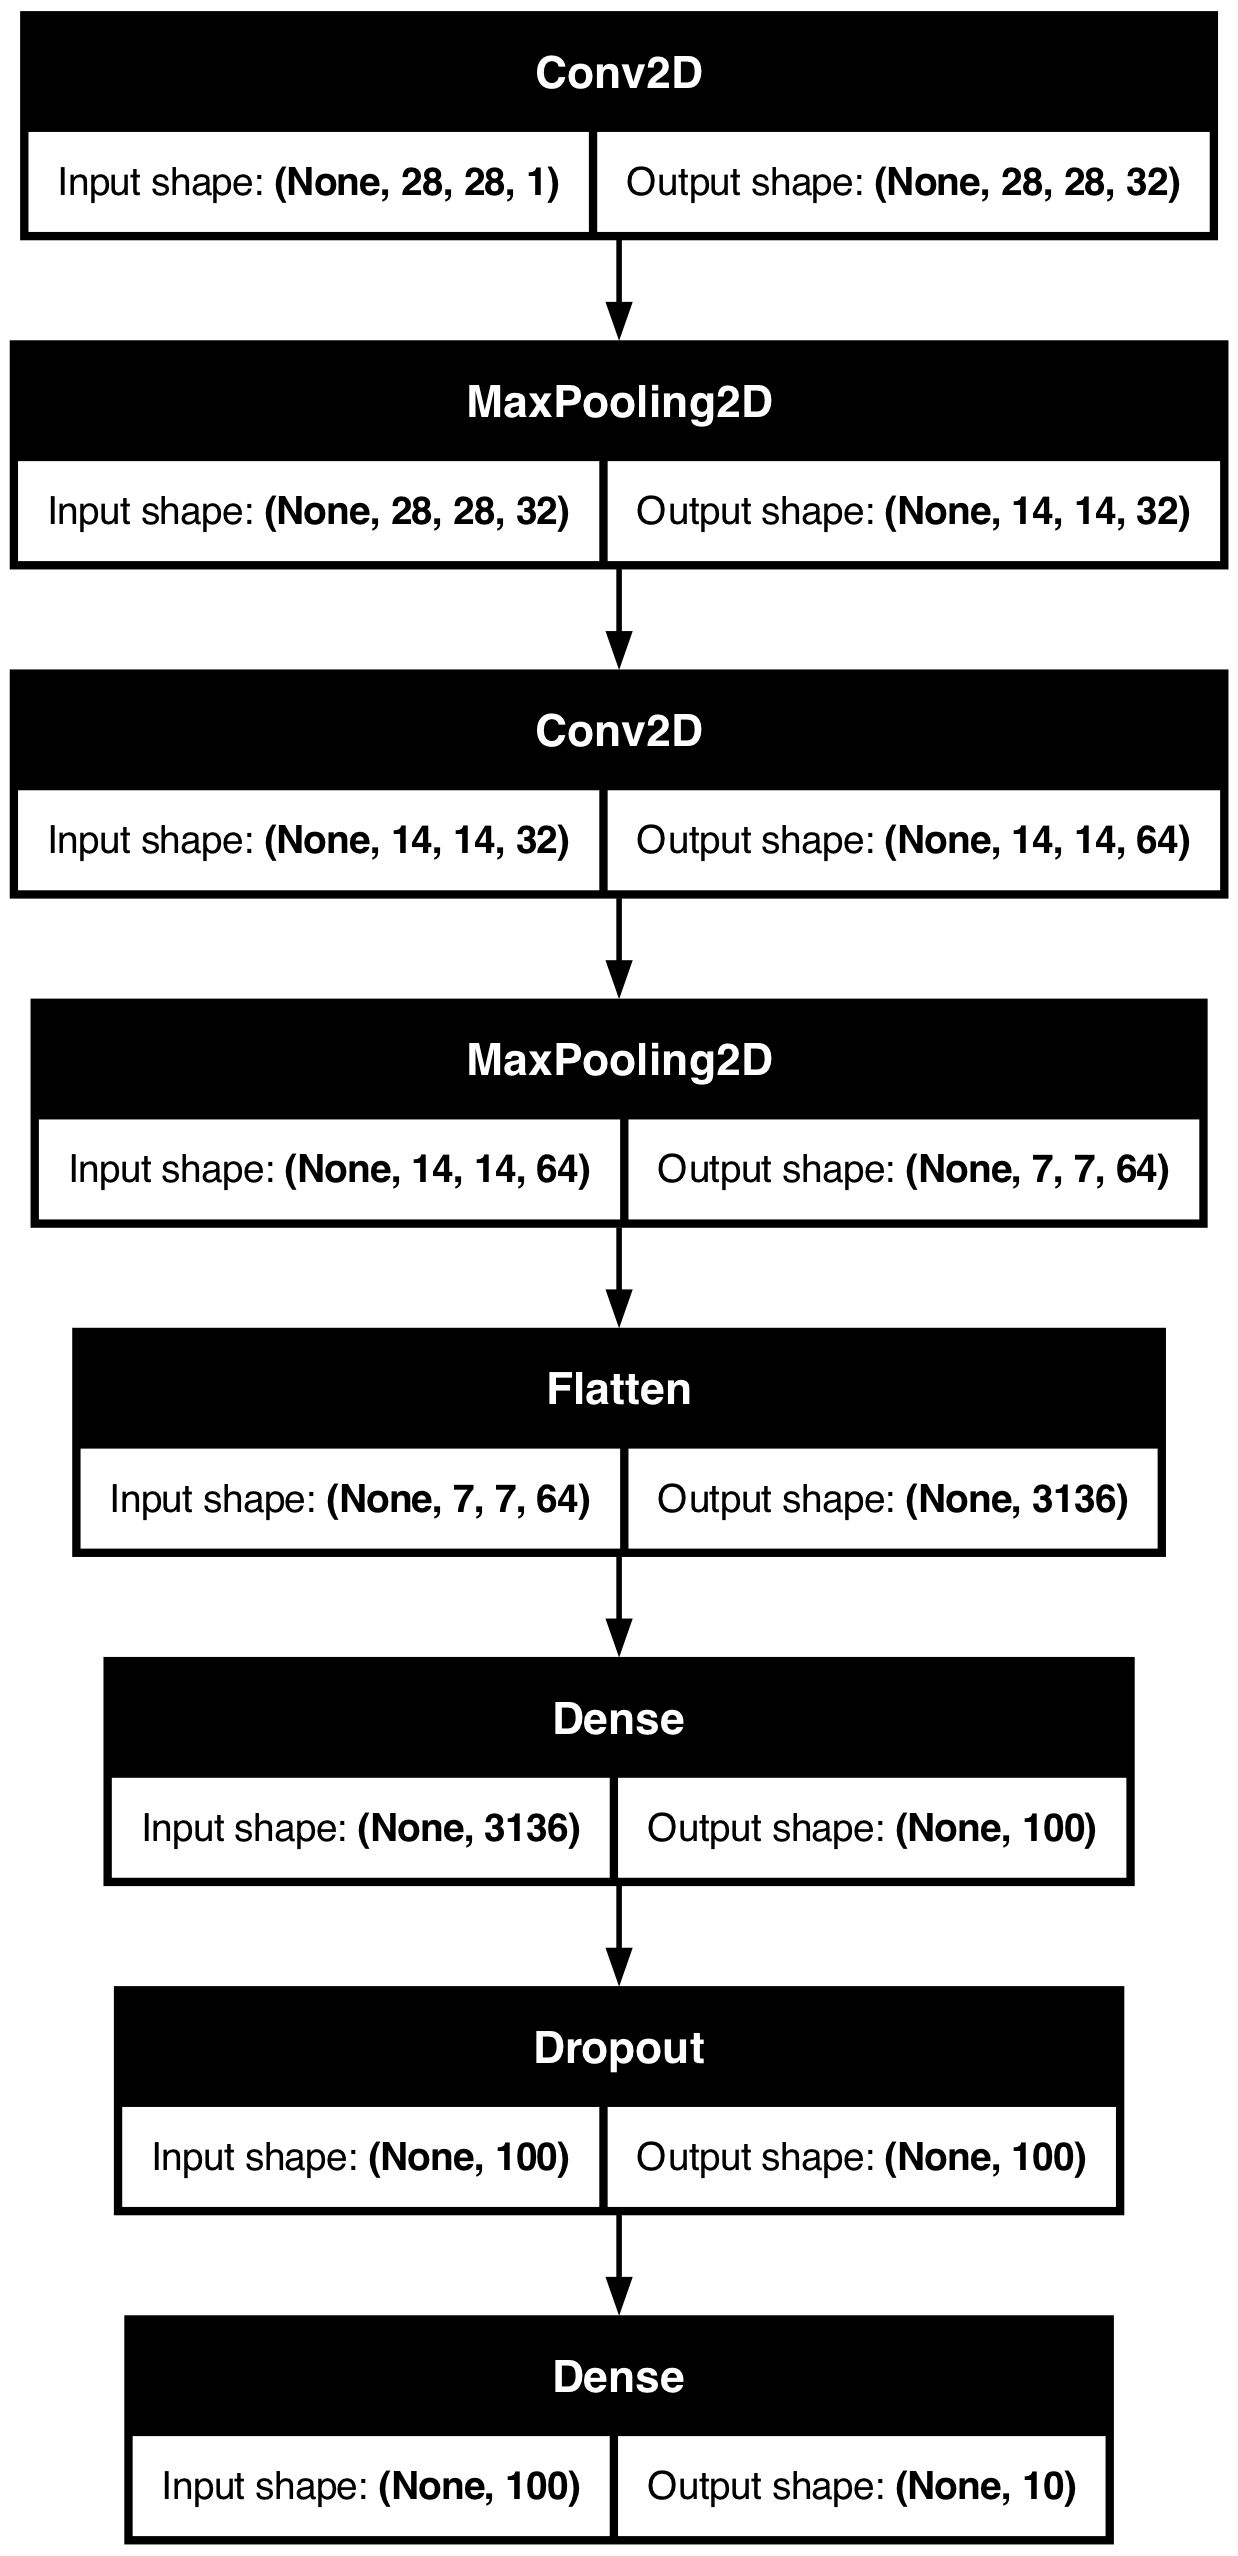

In [23]:
keras.utils.plot_model(model, show_shapes=True)

In [28]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras', save_best_only=True)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8062 - loss: 0.5355 - val_accuracy: 0.8765 - val_loss: 0.3461
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8712 - loss: 0.3572 - val_accuracy: 0.8966 - val_loss: 0.2837
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8924 - loss: 0.3023 - val_accuracy: 0.9027 - val_loss: 0.2633
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9018 - loss: 0.2716 - val_accuracy: 0.9087 - val_loss: 0.2435
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9105 - loss: 0.2468 - val_accuracy: 0.9144 - val_loss: 0.2291
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9176 - loss: 0.2228 - val_accuracy: 0.9196 - val_loss: 0.2256
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9245 - loss: 0.2030 - val_accuracy: 0.9196 - val_loss: 0.2217
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9301 - 

In [29]:
import matplotlib.pyplot as plt

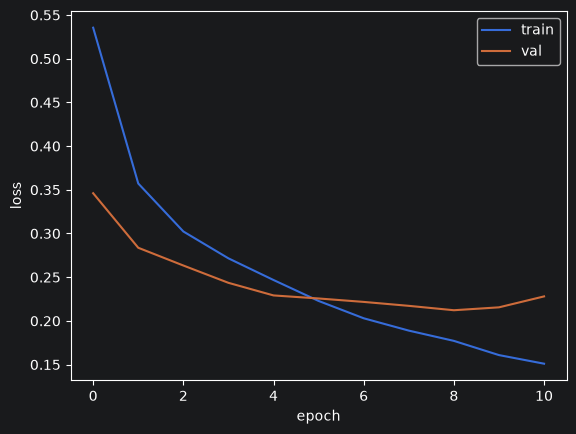

In [30]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch',)
plt.ylabel('loss')
plt.legend()
plt.show()

In [31]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9231 - loss: 0.2122 


[0.2121681571006775, 0.9230833053588867]

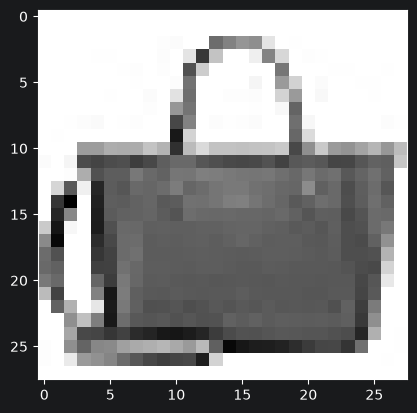

In [32]:
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [34]:
prds = model.predict(val_scaled[0:1])
print(prds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[4.7954953e-14 6.0618215e-21 1.6647866e-15 1.1361381e-17 3.3437686e-14
  6.2294051e-15 3.7867086e-15 3.3341202e-14 1.0000000e+00 4.0285166e-15]]


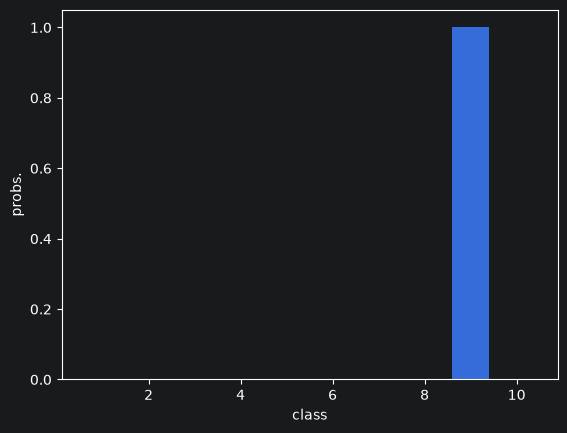

In [35]:
plt.bar(range(1, 11), prds[0])
plt.xlabel('class')
plt.ylabel('probs.')
plt.show()

In [36]:
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']

In [37]:
import numpy as np

In [38]:
print(classes[np.argmax(prds)])

가방


In [40]:
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [41]:
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9156 - loss: 0.2456


[0.2455606758594513, 0.9156000018119812]